La CNN-1D es una buena candidata para cerrar la comparativa de modelos de deep learning del TFG.

Frente al MLP, puede capturar patrones locales entre variables consecutivas dentro de una ventana. Frente a la LSTM, suele ser mas ligera y mas facil de entrenar. En este notebook seguimos el mismo patron general: Optuna multiobjetivo con F1 y latencia, seleccion de candidatos desde la frontera de Pareto, evaluacion final en test y benchmark de recursos del modelo ganador.

In [4]:
import os
import time
import numpy as np
import polars as pl
import optuna
import psutil
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

HAS_GPU = len(tf.config.list_physical_devices('GPU')) > 0
TRAIN_DEVICE = '/GPU:0' if HAS_GPU else '/CPU:0'
INFER_DEVICE = '/CPU:0'

if HAS_GPU:
    print('GPU detectada. El entrenamiento se ejecutara en GPU y la inferencia se medira en CPU.')
else:
    print('No hay GPU disponible. Entrenamiento e inferencia se ejecutaran en CPU.')

tf.keras.backend.clear_session()


GPU detectada. El entrenamiento se ejecutara en GPU y la inferencia se medira en CPU.


In [5]:
DEFAULT_DROPOUT_RATE = 0.2

def build_cnn1d_model(n_features, n_filters, kernel_size, dense_units, dropout_rate=DEFAULT_DROPOUT_RATE):
    model = keras.Sequential([
        keras.layers.Input(shape=(n_features, 1)), # <-- Forma tabular (características como secuencia)
        keras.layers.Conv1D(filters=n_filters, kernel_size=kernel_size, padding='same', activation='relu'),
        keras.layers.MaxPooling1D(pool_size=2),
        keras.layers.Conv1D(filters=max(16, n_filters // 2), kernel_size=kernel_size, padding='same', activation='relu'),
        keras.layers.GlobalMaxPooling1D(),
        keras.layers.Dense(dense_units, activation='relu'),
        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def clone_model_to_cpu(trained_model, n_features, n_filters, kernel_size, dense_units, dropout_rate):
    with tf.device(INFER_DEVICE):
        cpu_model = build_cnn1d_model(
            n_features=n_features,
            n_filters=n_filters,
            kernel_size=kernel_size,
            dense_units=dense_units,
            dropout_rate=dropout_rate
        )
        cpu_model.set_weights(trained_model.get_weights())
    return cpu_model

# --- CARGA DEL DATASET UNSW-NB15 ---
path_train = '../../DATASETS/dataSets_Reducidos/nusw-nb15/datos_train_NUSW_redux.csv'
path_test  = '../../DATASETS/dataSets_Reducidos/nusw-nb15/datos_test_NUSW_redux.csv'

df_train = pl.read_csv(path_train)
df_test  = pl.read_csv(path_test)
TARGET_COL = 'attack_cat'

y_train = (
    df_train.select(
        pl.when(pl.col(TARGET_COL).str.strip_chars() == 'Normal')
        .then(1)
        .otherwise(-1)
        .alias('label')
    )
    .to_series()
    .cast(pl.Int8)
)

y_test = (
    df_test.select(
        pl.when(pl.col(TARGET_COL).str.strip_chars() == 'Normal')
        .then(1)
        .otherwise(-1)
        .alias('label')
    )
    .to_series()
    .cast(pl.Int8)
)

x_train = df_train.drop(TARGET_COL)
x_test = df_test.drop(TARGET_COL)

X_full_train = x_train.to_numpy()
y_full_train = y_train.to_numpy()
X_test_np = x_test.to_numpy()
y_test_np = y_test.to_numpy()

# Convertimos de {-1, 1} a {0, 1} para la entropía cruzada binaria
y_full_train_01 = ((y_full_train + 1) // 2).astype(np.int8)
y_test_np01 = ((y_test_np + 1) // 2).astype(np.int8)

X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(
    X_full_train,
    y_full_train,
    test_size=0.2,
    random_state=42,
    stratify=y_full_train
)

print(f'Forma de X_full_train: {X_full_train.shape}')
print(f'Forma de X_test: {X_test_np.shape}')
print('Distribución de clases en train:')
print(y_train.value_counts())
print('Distribución de clases en test:')
print(y_test.value_counts())
print('\nNota metodológica: La CNN-1D procesa cada flujo de forma independiente como un vector tabular, utilizando las características extraídas para encontrar correlaciones locales.')

Forma de X_full_train: (175341, 12)
Forma de X_test: (82332, 12)
Distribución de clases en train:
shape: (2, 2)
┌───────┬────────┐
│ label ┆ count  │
│ ---   ┆ ---    │
│ i8    ┆ u32    │
╞═══════╪════════╡
│ 1     ┆ 56000  │
│ -1    ┆ 119341 │
└───────┴────────┘
Distribución de clases en test:
shape: (2, 2)
┌───────┬───────┐
│ label ┆ count │
│ ---   ┆ ---   │
│ i8    ┆ u32   │
╞═══════╪═══════╡
│ 1     ┆ 37000 │
│ -1    ┆ 45332 │
└───────┴───────┘

Nota metodológica: La CNN-1D procesa cada flujo de forma independiente como un vector tabular, utilizando las características extraídas para encontrar correlaciones locales.


In [7]:
# ==========================================
# 2. OPTUNA MULTIOBJETIVO: F1 Y LATENCIA
# ==========================================

def objective(trial):
    tf.keras.backend.clear_session()

    n_filters = trial.suggest_int('n_filters', 32, 128, step=32)
    kernel_size = trial.suggest_int('kernel_size', 2, 5) # Valores clásicos para tabular
    dense_units = trial.suggest_int('dense_units', 16, 96, step=16)
    
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    f1_scores = []
    inference_times = []

    for train_idx, val_idx in skf.split(X_full_train, y_full_train_01):
        X_train_fold = X_full_train[train_idx]
        y_train_fold = y_full_train_01[train_idx]
        X_val_fold = X_full_train[val_idx]
        y_val_fold = y_full_train_01[val_idx]

        # 1. Escalado Min-Max
        scaler = MinMaxScaler()
        X_train_fold_scaled = scaler.fit_transform(X_train_fold)
        X_val_fold_scaled = scaler.transform(X_val_fold)

        # 2. Reshape Tabular a 3D para la Conv1D (muestras, features, canales)
        X_train_cnn = X_train_fold_scaled.reshape(X_train_fold_scaled.shape[0], X_train_fold_scaled.shape[1], 1)
        X_val_cnn = X_val_fold_scaled.reshape(X_val_fold_scaled.shape[0], X_val_fold_scaled.shape[1], 1)
        
        n_features = X_train_cnn.shape[1]

        with tf.device(INFER_DEVICE):
            model = build_cnn1d_model(
                n_features=n_features,
                n_filters=n_filters,
                kernel_size=kernel_size,
                dense_units=dense_units,
                dropout_rate=DEFAULT_DROPOUT_RATE
            )

            early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
            model.fit(
                X_train_cnn,
                y_train_fold,
                validation_split=0.1,
                epochs=20,
                batch_size=1024,
                callbacks=[early_stop],
                verbose=0
            )

        cpu_model = clone_model_to_cpu(
            trained_model=model,
            n_features=n_features,
            n_filters=n_filters,
            kernel_size=kernel_size,
            dense_units=dense_units,
            dropout_rate=DEFAULT_DROPOUT_RATE
        )

        with tf.device(INFER_DEVICE):
            y_pred_prob = cpu_model.predict(X_val_cnn, batch_size=1024, verbose=0).ravel()

        y_pred = (y_pred_prob > 0.5).astype(np.int8)
        f1_scores.append(f1_score(y_val_fold, y_pred, average='binary', zero_division=0))

        X_lat = X_val_cnn[:min(20000, len(X_val_cnn))]
        if len(X_lat) == 0:
            continue

        with tf.device(INFER_DEVICE):
            _ = cpu_model.predict(X_lat[:min(512, len(X_lat))], batch_size=512, verbose=0)

        rep_lat = []
        for _ in range(3):
            with tf.device(INFER_DEVICE):
                t0 = time.perf_counter()
                _ = cpu_model.predict(X_lat, batch_size=1024, verbose=0)
                t1 = time.perf_counter()
            rep_lat.append((t1 - t0) / len(X_lat))

        inference_times.append(float(np.mean(rep_lat)))

        tf.keras.backend.clear_session()

    return float(np.mean(f1_scores)), float(np.mean(inference_times))

study = optuna.create_study(directions=['maximize', 'minimize'], study_name='cnn1d_unsw_optimization')
print('Iniciando barrido multiobjetivo con CNN-1D (entrenamiento en GPU, inferencia medida en CPU)...')
study.optimize(objective, n_trials=25, show_progress_bar=True)

results = []
pareto_trials = {trial.number for trial in study.best_trials}
for trial in study.trials:
    if trial.values is None:
        continue

    row = {
        'Trial': trial.number,
        'F1_CV': float(trial.values[0]),
        'Latencia_ms': float(trial.values[1] * 1000),
        'Pareto': trial.number in pareto_trials
    }
    row.update(trial.params)
    results.append(row)

df_cnn_trials = pl.DataFrame(results).sort(['Pareto', 'F1_CV', 'Latencia_ms'], descending=[True, True, False])
df_cnn_trials.write_csv('cnn1d_unsw_trials_results_cv.csv')
print("\nResultados guardados en 'cnn1d_unsw_trials_results_cv.csv'")
print(df_cnn_trials)

[I 2026-04-27 23:21:52,140] A new study created in memory with name: cnn1d_unsw_optimization


Iniciando barrido multiobjetivo con CNN-1D (entrenamiento en GPU, inferencia medida en CPU)...


  0%|          | 0/25 [00:00<?, ?it/s]W0000 00:00:1777324913.284703  592621 platform_util.cc:146] Allowed device set contains 4 devices, but platform only sees 1
I0000 00:00:1777324913.303564  592621 service.cc:153] XLA service 0x7f7d7c6368f0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777324913.303596  592621 service.cc:161]   StreamExecutor [0]: Host, Default Version (Driver: 0.0.0; Runtime: 0.0.0; Toolkit: 0.0.0; DNN: 0.0.0)
I0000 00:00:1777324913.875863  592621 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
  4%|▍         | 1/25 [00:55<22:22, 55.93s/it]

[I 2026-04-27 23:22:48,072] Trial 0 finished with values: [0.8551603972540213, 8.637378355746883e-06] and parameters: {'n_filters': 128, 'kernel_size': 3, 'dense_units': 16}.


  8%|▊         | 2/25 [01:52<21:34, 56.30s/it]

...

[I 2026-04-27 23:39:07,803] Trial 22 finished with values: [0.8465129159731353, 8.563050039164307e-06] and parameters: {'n_filters': 32, 'kernel_size': 5, 'dense_units': 64}.


 96%|█████████▌| 24/25 [17:56<00:41, 41.26s/it]

[I 2026-04-27 23:39:48,633] Trial 23 finished with values: [0.8514522910269188, 8.596133677444111e-06] and parameters: {'n_filters': 96, 'kernel_size': 4, 'dense_units': 48}.


100%|██████████| 25/25 [18:45<00:00, 45.02s/it]

[I 2026-04-27 23:40:37,569] Trial 24 finished with values: [0.8502402383874639, 8.733884883501255e-06] and parameters: {'n_filters': 128, 'kernel_size': 2, 'dense_units': 96}.

Resultados guardados en 'cnn1d_unsw_trials_results_cv.csv'
shape: (25, 7)
┌───────┬──────────┬─────────────┬────────┬───────────┬─────────────┬─────────────┐
│ Trial ┆ F1_CV    ┆ Latencia_ms ┆ Pareto ┆ n_filters ┆ kernel_size ┆ dense_units │
│ ---   ┆ ---      ┆ ---         ┆ ---    ┆ ---       ┆ ---         ┆ ---         │
│ i64   ┆ f64      ┆ f64         ┆ bool   ┆ i64       ┆ i64         ┆ i64         │
╞═══════╪══════════╪═════════════╪════════╪═══════════╪═════════════╪═════════════╡
│ 15    ┆ 0.861494 ┆ 0.00861     ┆ true   ┆ 64        ┆ 5           ┆ 64          │
│ 1     ┆ 0.860251 ┆ 0.008416    ┆ true   ┆ 96        ┆ 5           ┆ 64          │
│ 5     ┆ 0.850186 ┆ 0.008245    ┆ true   ┆ 32        ┆ 2           ┆ 96          │
│ 17    ┆ 0.846972 ┆ 0.008204    ┆ true   ┆ 96        ┆ 2           ┆ 64     

Trial,F1_CV,Latencia_ms,Pareto,n_filters,kernel_size,dense_units
i64,f64,f64,bool,i64,i64,i64
10,0.844645,0.008188,true,32,3,16
17,0.846972,0.008204,true,96,2,64
5,0.850186,0.008245,true,32,2,96
1,0.860251,0.008416,true,96,5,64
15,0.861494,0.00861,true,64,5,64


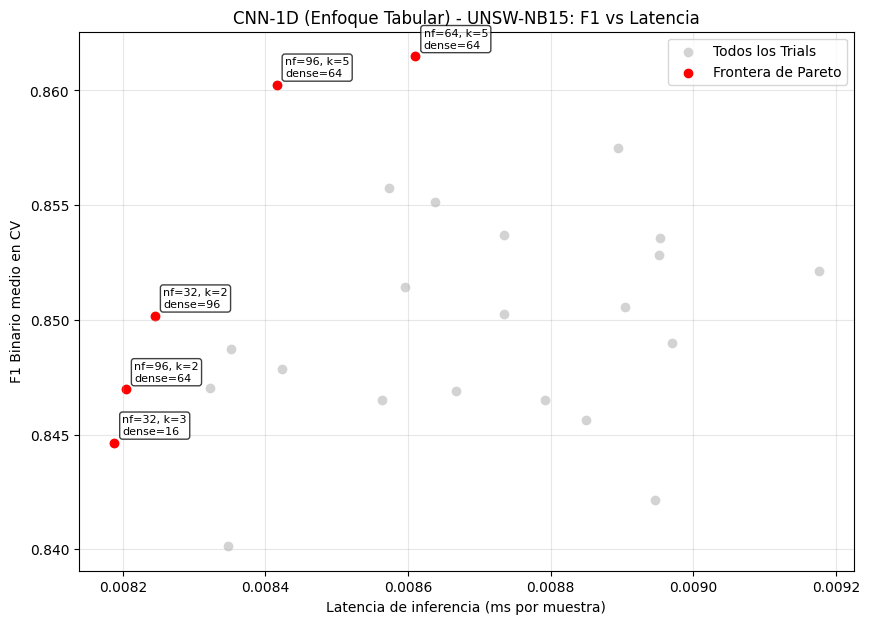

In [8]:
import polars as pl
import matplotlib.pyplot as plt

# 1. Leer resultados desde el CSV específico de UNSW-NB15
df_cnn_trials = pl.read_csv("cnn1d_unsw_trials_results_cv.csv")

# 2. Filtrar la frontera de Pareto
df_pareto = (
    df_cnn_trials
    .filter(pl.col("Pareto") == True)
    .sort("Latencia_ms")
)

display(df_pareto)

# 3. Configurar la gráfica
plt.figure(figsize=(10, 7))

# Puntos grises para todos los intentos (Trials)
plt.scatter(
    df_cnn_trials["Latencia_ms"],
    df_cnn_trials["F1_CV"],
    c="lightgray",
    label="Todos los Trials"
)

# Puntos rojos para los óptimos (Frontera de Pareto)
plt.scatter(
    df_pareto["Latencia_ms"],
    df_pareto["F1_CV"],
    c="red",
    label="Frontera de Pareto"
)

# 4. Mostrar hiperparámetros de los puntos Pareto (¡Sin time_steps!)
for row in df_pareto.iter_rows(named=True):
    # Formateamos el texto solo con los hiperparámetros que hemos usado
    texto = (
        f"nf={row['n_filters']}, k={row['kernel_size']}\n"
        f"dense={row['dense_units']}"
    )
    plt.annotate(
        texto,
        (row["Latencia_ms"], row["F1_CV"]),
        textcoords="offset points",
        xytext=(6, 6),
        ha="left",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.75)
    )

# 5. Etiquetas y formato final
plt.xlabel("Latencia de inferencia (ms por muestra)")
plt.ylabel("F1 Binario medio en CV")
plt.title("CNN-1D (Enfoque Tabular) - UNSW-NB15: F1 vs Latencia")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
import gc
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score, accuracy_score

# ==========================================
# 4. EVALUACION FINAL EN TEST (CNN-1D TABULAR)
# ==========================================

# OJO: He eliminado el parámetro 'ts'. 
# ¡Asegúrate de poner aquí los verdaderos ganadores de tu Optuna sin secuencias!
candidatos = [
    {'nf': 96, 'k': 3, 'd': 32, 'nombre': 'Candidato 1'},
    {'nf': 96, 'k': 3, 'd': 80, 'nombre': 'Candidato 2'},
    {'nf': 32, 'k': 4, 'd': 96, 'nombre': 'Candidato 3'},
    {'nf': 64, 'k': 4, 'd': 80, 'nombre': 'Candidato 4'},
    {'nf': 64, 'k': 3, 'd': 64, 'nombre': 'Candidato 5'},
]

resultados_finales = []

print('--- EVALUACION FINAL SOBRE EL SET DE TEST (CNN-1D TABULAR) ---\n')

for c in candidatos:
    tf.keras.backend.clear_session()
    print(
        f"Probando {c['nombre']}: Filtros={c['nf']}, "
        f"Kernel={c['k']}, Dense={c['d']}"
    )

    n_filters = int(c['nf'])
    kernel_size = int(c['k'])
    dense_units = int(c['d'])

    # 1. Usamos MinMaxScaler en lugar de StandardScaler (Vital para CNN)
    scaler = MinMaxScaler()
    X_full_train_scaled = scaler.fit_transform(X_full_train)
    X_test_scaled = scaler.transform(X_test_np)

    # 2. Reshape Tabular a 3D (muestras, features, canales)
    X_train_cnn = X_full_train_scaled.reshape(X_full_train_scaled.shape[0], X_full_train_scaled.shape[1], 1)
    X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)
    
    n_features = X_train_cnn.shape[1]

    with tf.device(TRAIN_DEVICE):
        model = build_cnn1d_model(
            n_features=n_features,
            n_filters=n_filters,
            kernel_size=kernel_size,
            dense_units=dense_units,
            dropout_rate=DEFAULT_DROPOUT_RATE
        )

        early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
        model.fit(
            X_train_cnn,
            y_full_train_01, # Usamos las etiquetas 0/1 correctas
            validation_split=0.1,
            epochs=20,
            batch_size=512,  # Reducido a 512 para no saturar la GPU
            callbacks=[early_stop],
            verbose=0
        )

    # Clonamos a CPU para una medición de latencia justa
    cpu_model = clone_model_to_cpu(
        trained_model=model,
        n_features=n_features,
        n_filters=n_filters,
        kernel_size=kernel_size,
        dense_units=dense_units,
        dropout_rate=DEFAULT_DROPOUT_RATE
    )

    with tf.device(INFER_DEVICE):
        y_prob = cpu_model.predict(X_test_cnn, batch_size=1024, verbose=0).ravel()
    
    y_pred = (y_prob > 0.5).astype(np.int8)

    # Preparar datos para latencia
    X_lat = X_test_cnn[:min(20000, len(X_test_cnn))]
    if len(X_lat) == 0:
        raise ValueError('No hay suficientes muestras en test para medir latencia con la configuracion seleccionada.')

    # Calentamiento (Warm-up)
    with tf.device(INFER_DEVICE):
        _ = cpu_model.predict(X_lat[:min(512, len(X_lat))], batch_size=512, verbose=0)

    # Medición real
    rep_lat = []
    for _ in range(3):
        with tf.device(INFER_DEVICE):
            t0 = time.perf_counter()
            _ = cpu_model.predict(X_lat, batch_size=1024, verbose=0)
            t1 = time.perf_counter()
        rep_lat.append((t1 - t0) / len(X_lat))

    # Cálculo final de métricas (evaluando sobre y_test_np01)
    f1_test = float(f1_score(y_test_np01, y_pred, average='binary', zero_division=0))
    acc_test = float(accuracy_score(y_test_np01, y_pred))
    lat_ms = float(np.mean(rep_lat) * 1000)

    resultados_finales.append({
        'Perfil': c['nombre'],
        'n_filters': n_filters,
        'kernel_size': kernel_size,
        'dense_units': dense_units,
        'F1_Test': f1_test,
        'Accuracy_Test': acc_test,
        'Latencia_ms': lat_ms
    })
    print(f"  -> F1={f1_test:.4f} | Acc={acc_test:.4f} | Latencia={lat_ms:.6f} ms")

    # Limpieza estricta de memoria
    del model
    del cpu_model
    tf.keras.backend.clear_session()
    gc.collect()

# Mostrar DataFrame final
df_candidate_results = pl.DataFrame(resultados_finales).sort(['F1_Test', 'Latencia_ms'], descending=[True, False])

print('\n' + '=' * 88)
print('              TABLA COMPARATIVA FINAL (CNN-1D TABULAR - TEST SET)')
print('=' * 88)
print(df_candidate_results)

--- EVALUACION FINAL SOBRE EL SET DE TEST (CNN-1D) ---

Probando Candidato 1: TS=15, Filtros=96, Kernel=3, Dense=32


I0000 00:00:1774465044.389412 2541394 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43487 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:4a:00.0, compute capability: 8.9
I0000 00:00:1774465044.390556 2541394 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 43487 MB memory:  -> device: 1, name: NVIDIA L40S, pci bus id: 0000:61:00.0, compute capability: 8.9
I0000 00:00:1774465044.391913 2541394 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 43487 MB memory:  -> device: 2, name: NVIDIA L40S, pci bus id: 0000:ca:00.0, compute capability: 8.9
I0000 00:00:1774465044.392978 2541394 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 43487 MB memory:  -> device: 3, name: NVIDIA L40S, pci bus id: 0000:e1:00.0, compute capability: 8.9
I0000 00:00:1774465046.349447 2546717 service.cc:153] XLA service 0x7f31a4032190 initialized for platfor

  -> F1=0.9193 | Acc=0.9326 | Latencia=0.009589 ms
Probando Candidato 2: TS=12, Filtros=96, Kernel=3, Dense=80


I0000 00:00:1774465063.574536 2546717 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_13613__.21
I0000 00:00:1774465063.623408 2546717 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774465064.081227 2546717 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774465064.828977 2546717 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774465068.09985

  -> F1=0.9056 | Acc=0.9218 | Latencia=0.009613 ms
Probando Candidato 3: TS=15, Filtros=32, Kernel=4, Dense=96


...

  -> F1=0.9077 | Acc=0.9236 | Latencia=0.009057 ms
Probando Candidato 4: TS=7, Filtros=64, Kernel=4, Dense=80


I0000 00:00:1774465092.357760 2546717 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_32030__.21
I0000 00:00:1774465092.500291 2546717 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774465095.922030 2546717 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_32030__.21
I0000 00:00:1774465095.977542 2546717 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774465096.549514 2546717 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a g

  -> F1=0.8975 | Acc=0.9151 | Latencia=0.008658 ms
Probando Candidato 5: TS=9, Filtros=64, Kernel=3, Dense=64


I0000 00:00:1774465106.761267 2546716 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_40879__.21
I0000 00:00:1774465107.037408 2546716 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774465110.365318 2546716 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_40879__.21
I0000 00:00:1774465110.411662 2546716 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774465110.972884 2546716 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a g

  -> F1=0.8925 | Acc=0.9121 | Latencia=0.008549 ms

              TABLA COMPARATIVA FINAL (CNN-1D - TEST SET)
shape: (5, 8)
┌────────────┬────────────┬───────────┬────────────┬────────────┬──────────┬───────────┬───────────┐
│ Perfil     ┆ time_steps ┆ n_filters ┆ kernel_siz ┆ dense_unit ┆ F1_Test  ┆ Accuracy_ ┆ Latencia_ │
│ ---        ┆ ---        ┆ ---       ┆ e          ┆ s          ┆ ---      ┆ Test      ┆ ms        │
│ str        ┆ i64        ┆ i64       ┆ ---        ┆ ---        ┆ f64      ┆ ---       ┆ ---       │
│            ┆            ┆           ┆ i64        ┆ i64        ┆          ┆ f64       ┆ f64       │
╞════════════╪════════════╪═══════════╪════════════╪════════════╪══════════╪═══════════╪═══════════╡
│ Candidato  ┆ 15         ┆ 96        ┆ 3          ┆ 32         ┆ 0.919338 ┆ 0.932591  ┆ 0.009589  │
│ 1          ┆            ┆           ┆            ┆            ┆          ┆           ┆           │
│ Candidato  ┆ 15         ┆ 32        ┆ 4          ┆ 96         ┆ 0.

In [ ]:
# ==========================================
# 5. ROC, MATRIZ DE CONFUSION Y BENCHMARK FINAL
# ==========================================

tf.keras.backend.clear_session()

time_steps = int(best_c['ts'])
n_filters = int(best_c['nf'])
kernel_size = int(best_c['k'])
dense_units = int(best_c['d'])
scaler_best = StandardScaler()
X_full_train_scaled = scaler_best.fit_transform(X_full_train)
X_test_scaled = scaler_best.transform(X_test_np)

X_train_seq, y_train_seq = create_sequences(X_full_train_scaled, y_full_train_01, time_steps)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_np01, time_steps)

with tf.device(TRAIN_DEVICE):
    model_final = build_cnn1d_model(
        time_steps=time_steps,
        n_features=X_train_seq.shape[2],
        n_filters=n_filters,
        kernel_size=kernel_size,
        dense_units=dense_units,
        dropout_rate=DEFAULT_DROPOUT_RATE
    )

    early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    model_final.fit(
        X_train_seq,
        y_train_seq,
        validation_split=0.1,
        epochs=20,
        batch_size=1024,
        callbacks=[early_stop],
        verbose=0
    )

model_final_cpu = clone_model_to_cpu(
    trained_model=model_final,
    time_steps=time_steps,
    n_features=X_train_seq.shape[2],
    n_filters=n_filters,
    kernel_size=kernel_size,
    dense_units=dense_units,
    dropout_rate=DEFAULT_DROPOUT_RATE
)

# ==========================================
# 5.1 BENCHMARK DE RECURSOS COMPUTACIONALES
# ==========================================
print('Midiendo recursos computacionales del modelo ganador (CNN-1D)...')
proceso = psutil.Process(os.getpid())
block_size = 2048
repetitions = 3

with tf.device(INFER_DEVICE):
    _ = model_final_cpu.predict(X_test_seq[:min(512, len(X_test_seq))], batch_size=512, verbose=0)

tiempos_muro = []
tiempos_cpu = []
picos_ram = []

for _ in range(repetitions):
    cpu_ini = proceso.cpu_times()
    ram_base = proceso.memory_info().rss / (1024 * 1024)
    pico_ram_rep = ram_base

    t0 = time.perf_counter()
    for inicio in range(0, len(X_test_seq), block_size):
        fin = inicio + block_size
        bloque = X_test_seq[inicio:fin]
        with tf.device(INFER_DEVICE):
            _ = model_final_cpu.predict(bloque, batch_size=512, verbose=0)

        ram_actual = proceso.memory_info().rss / (1024 * 1024)
        if ram_actual > pico_ram_rep:
            pico_ram_rep = ram_actual

    t1 = time.perf_counter()
    cpu_fin = proceso.cpu_times()

    tiempos_muro.append(t1 - t0)
    tiempos_cpu.append((cpu_fin.user - cpu_ini.user) + (cpu_fin.system - cpu_ini.system))
    picos_ram.append(pico_ram_rep - ram_base)

media_muro = float(np.mean(tiempos_muro))
media_cpu = float(np.mean(tiempos_cpu))
pico_max_ram = float(np.max(picos_ram))
total_nucleos = psutil.cpu_count(logical=True)

df_benchmark_cnn1d = pl.DataFrame([{
    'Modelo': 'CNN-1D',
    'Latencia_ms': round((media_muro / len(X_test_seq)) * 1000, 5),
    'Thruput (paq/s)': round(len(X_test_seq) / media_muro, 0),
    'Nucleos CPU': round(media_cpu / media_muro if media_muro > 0 else 1, 1),
    'Pico RAM (MB)': round(pico_max_ram, 2),
    'Porcentaje CPU': round(((media_cpu / media_muro) / total_nucleos) * 100 if media_muro > 0 else 0, 1)
}])
print(df_benchmark_cnn1d)

# ==========================================
# 5.2 PREDICCIONES Y GRAFICAS
# ==========================================
with tf.device(INFER_DEVICE):
    y_pred_prob = model_final_cpu.predict(X_test_seq, batch_size=1024, verbose=0).ravel()
y_pred = (y_pred_prob > 0.5).astype(np.int8)

cm = confusion_matrix(y_test_seq, y_pred)
fpr, tpr, _ = roc_curve(y_test_seq, y_pred_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax[0],
    xticklabels=['Ataque (0)', 'Normal (1)'],
    yticklabels=['Ataque (0)', 'Normal (1)']
)
ax[0].set_title('Matriz de Confusion - CNN-1D')
ax[0].set_xlabel('Prediccion')
ax[0].set_ylabel('Realidad')

ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador aleatorio')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
ax[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax[1].set_title('Curva ROC - CNN-1D')
ax[1].legend(loc='lower right')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
